In [1]:
%matplotlib inline
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib
import scipy.io as sio

from matplotlib import cm

In [2]:
# read data
runname = 'debug_withC_rogers_netcdfBdy1_EB_soliton_withsponge_focus_finey_summer'
datafilepath = '/Volumes/Tan_2024/SUNTANS/NLIW/iwave2024/dongsha/'+runname+'/mfiles/'
datafilename = 'soliton_file_summer_smallAPE.mat'

# path to saved figures
outfilepath = '../figure/'

DJLEs = sio.loadmat(datafilepath+datafilename)

xc = DJLEs['DJLES_solution']['xc'][0][0].flatten()
zc = DJLEs['DJLES_solution']['zc'][0][0].flatten()
uc = DJLEs['DJLES_solution']['u'][0][0]
wc = DJLEs['DJLES_solution']['w'][0][0]
rho = DJLEs['DJLES_solution']['density'][0][0]

In [3]:
gamma = 2.1e-4
rho0 = 1000
temp = -(rho - rho0)/gamma/rho0

In [4]:
param_plot = {
    'var_name': 'temp',
    'vmax': 27,
    'vmin': 15,
    'slice_contour': np.arange(6,30,1), 
}

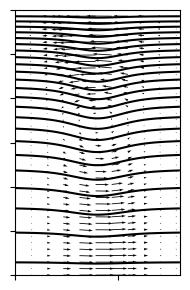

In [5]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(2,3))

ax.contour(xc, zc, temp, param_plot['slice_contour'], colors='k')
ax.quiver(xc[::100], zc[::50], -uc[::50,::100], -wc[::50,::100], scale=1, scale_units='inches', width=5e-3)
# ax.pcolormesh(xc, zc, uc)

ax.set_xlim([0, 8000])
ax.set_ylim([-600, 0])
ax.set_xticklabels('')
ax.set_yticklabels('')
ax.set_xlabel('')
ax.set_ylabel('')
# ax.set_xticks(np.arange(x_c-30000,x_c+30000+1,10000))
# ax.set_yticks(np.arange(y_c-30000,y_c+30000+1,10000))
# ax.set_xticklabels(['-30','-20', '-10', '0', '10', '20','30'])
# ax.set_yticklabels(['-30','-20', '-10', '0', '10', '20','30'])
# ax.set_aspect('equal')
# ax.set_xlabel('x [km]', fontsize=15)
# ax.set_ylabel('z [m]', fontsize=15)
ax.set_title(f'')
ax.tick_params(axis='both', which='major', labelsize=15)
plt.rcParams["font.family"] = "Times New Roman"
plt.tight_layout()

plt.savefig(outfilepath+ f"DJLEsolution_summer_smallAPE.png", dpi=300, transparent=True)